In [1]:
import numpy as np
import torch
import torch.nn as nn

### Data preparation
data = np.genfromtxt('data.csv', delimiter=',')
x_data = torch.from_numpy(data[:,0:1]).float()
y_data = torch.from_numpy(data[:,1:]).float()

print('X\n', x_data)
print('y\n', y_data)

X
 tensor([[6.7000],
        [4.6000],
        [3.5000],
        [5.5000]])
y
 tensor([[9.1000],
        [5.9000],
        [4.6000],
        [6.7000]])


In [2]:
# Create a linear layer
linear = nn.Linear(1, 1)

# set value (for illustration)
linear.weight.data = torch.Tensor([[-0.34]])
linear.bias.data = torch.Tensor([0.04])

# print
print(linear.weight)
print(linear.bias)

Parameter containing:
tensor([[-0.3400]], requires_grad=True)
Parameter containing:
tensor([0.0400], requires_grad=True)


In [3]:
# some params
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(linear.parameters(), 
                            lr=0.01)
epochs = 1000

In [4]:
# training
losses = []
for epoch in range(epochs):
    # y_hat
    y_hat = linear(x_data)
    
    # loss        
    loss = loss_fn(y_hat, y_data)
    losses.append(loss.item())
                
    # compute gradient
    optimizer.zero_grad()
    loss.backward()

    # update
    optimizer.step()

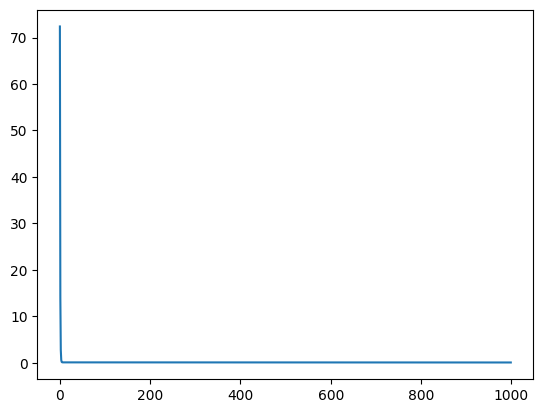

In [5]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [6]:
linear.weight

Parameter containing:
tensor([[1.3218]], requires_grad=True)

In [7]:
linear.bias

Parameter containing:
tensor([-0.1198], requires_grad=True)